# <div style="color:#fff;display:fill;border-radius:10px;background-color:#013F;text-align:center;letter-spacing:0.1px;overflow:hidden;padding:20px;color:white;overflow:hidden;margin:0;font-size:100%">🏁 Classification Project - End to End Pipeline
</div>

# <div style="color:#ffd;display:fill;border-radius:10px;background-color:#004F98;text-align:center;letter-spacing:0.1px;overflow:hidden;padding:20px;color:white;overflow:hidden;margin:0;font-size:100%">📒 Breast Cancer  logistic regression
</div>

## Data Overview

This dataset is about breast cancer diagnosis. Breast cancer is one of the most common cancers among women worldwide. The main challenge is to classify tumors as either malignant or benign based on different medical measurements.

The target column is `diagnosis`.

- `M` means Malignant tumor, which means cancerous.
- `B` means Benign tumor, which means non-cancerous.

The dataset contains several numerical features related to the tumor, such as radius, texture, perimeter, area, smoothness, compactness, concavity, and symmetry.

The main objective of this project is to understand the dataset, perform exploratory data analysis, clean and prepare the data, and build a Logistic Regression model to predict the diagnosis type.

## 📚 Import Basics Libraries

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve
)

import pickle

## 📚 Reading Dataset and Load Data + Data Understanding.

In [5]:
#load Data:
df = pd.read_csv("breast-cancer.csv")
print('📌 First 10 rows of the dataset:')
df.head(10)

📌 First 10 rows of the dataset:


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
5,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440
6,844359,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,...,22.88,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368
7,84458202,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,...,17.06,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510
8,844981,M,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,...,15.49,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720
9,84501001,M,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,...,15.09,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750


## 📚 Data Shape:

In [3]:
print(f'📊 Data Shape: {df.shape}')

📊 Data Shape: (569, 32)


In [4]:
print(f'📊 Number of rows: {df.shape[0]}')
print(f'📊 Number of columns: {df.shape[1]}')

📊 Number of rows: 569
📊 Number of columns: 32


In [6]:
# Display last 5 rows
print('📌 Last 5 rows of the dataset:')
df.tail()

📌 Last 5 rows of the dataset:


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,9.456,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039


In [7]:
# General information about the dataset
print('📋 Dataset Information:')
df.info()

📋 Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  per

In [8]:
# Column names
print('📝 Column Names:')
print(df.columns.tolist())

📝 Column Names:
['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']


In [9]:
# Descriptive statistics for numerical columns
print('📊 Descriptive Statistics (Numerical):')
df.describe()

📊 Descriptive Statistics (Numerical):


,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [10]:
# Data types of each column
print('🔢 Data Types:')
print(df.dtypes)

🔢 Data Types:
id                           int64
diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
concav

## 🧹 Data Cleaning & Preprocessing:

In [11]:
# Check for missing values
print('❌ Missing Values in Each Column:')
null_counts = df.isnull().sum()
print(null_counts)

❌ Missing Values in Each Column:
id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


In [12]:
# Check for duplicate rows
duplicates_count = df.duplicated().sum()
print(f'🔍 Number of Duplicate Rows: {duplicates_count:}')

🔍 Number of Duplicate Rows: 0


In [13]:
# Check for duplicate Columns
duplicates_count = df.T.duplicated().sum()
print(f'🔍 Number of Duplicate Columns: {duplicates_count:}')

🔍 Number of Duplicate Columns: 0


# 📈 Exploratory Data Analysis (EDA)

diagnosis
B    357
M    212
Name: count, dtype: int64


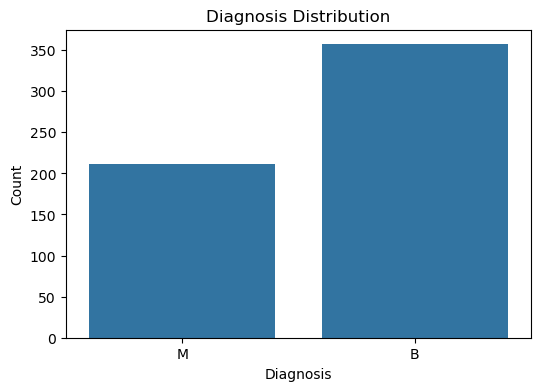

In [15]:
# Count of diagnosis values
print(df['diagnosis'].value_counts())
# Visualization
plt.figure(figsize=(6,4))
sns.countplot(x='diagnosis', data=df)
plt.title('Diagnosis Distribution')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.show()

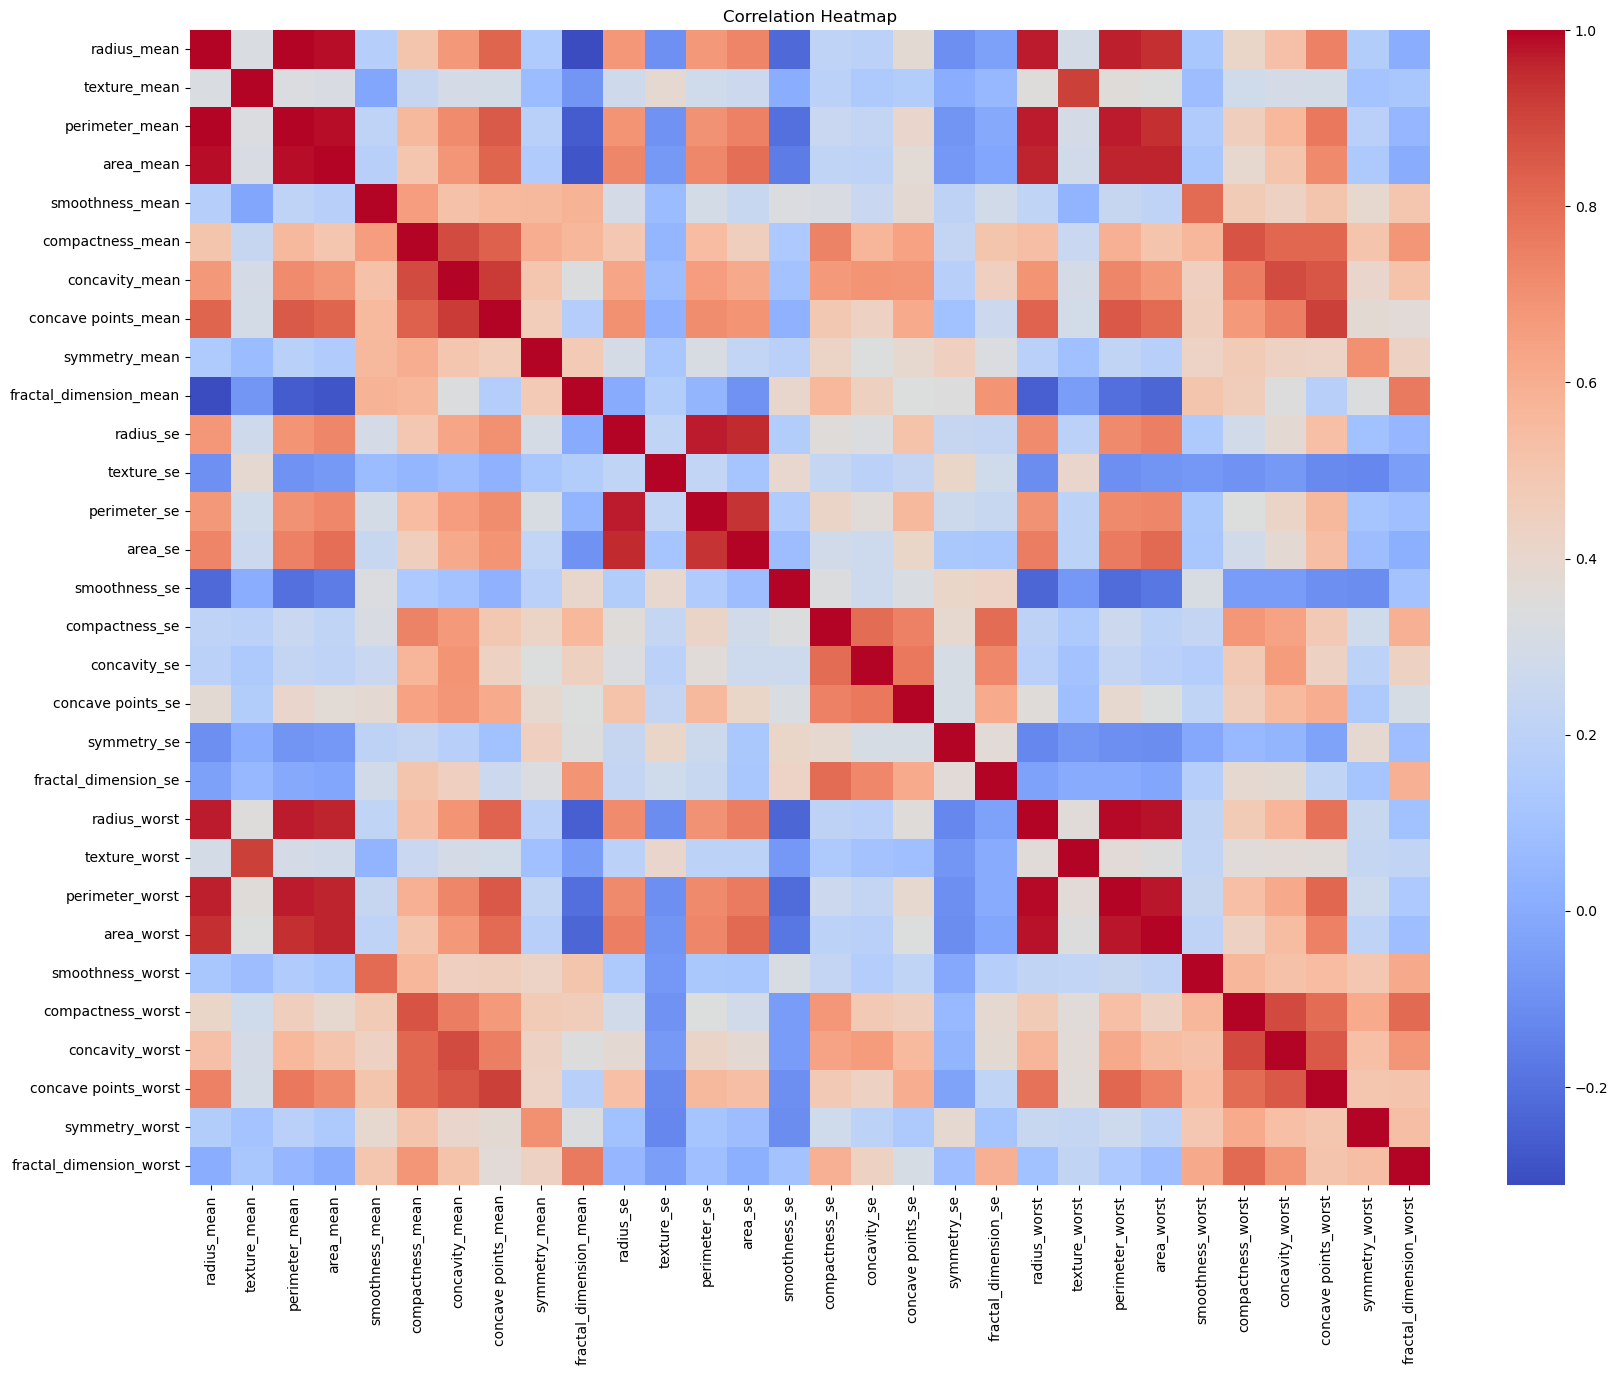

In [16]:
# Correlation matrix
corr_matrix = df.drop(['id'], axis=1).corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(20,15))

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    annot=False
)

plt.title('Correlation Heatmap')

plt.show()

## Insight

The correlation heatmap shows that several features have strong positive correlations with each other.

Features such as:
- radius_mean
- perimeter_mean
- area_mean

are highly correlated because they describe similar tumor characteristics.

Also, some "worst" features like:
- radius_worst
- perimeter_worst
- area_worst

show strong correlations as well.

This indicates that some features may contain similar information, which could affect the model due to multicollinearity.

In general, features related to tumor size and shape appear to be important for predicting the diagnosis type.

In [18]:
# Create encoder
label_encoder = LabelEncoder()
df['diagnosis'] = label_encoder.fit_transform(df['diagnosis'])
df['diagnosis'].value_counts()

diagnosis
0    357
1    212
Name: count, dtype: int64

## Insight Encoding

The diagnosis column was encoded using LabelEncoder.

- Benign (B) was converted to 0
- Malignant (M) was converted to 1

This transformation is necessary because machine learning models work with numerical values instead of categorical text labels.

In [19]:
# Drop id column
df = df.drop('id', axis=1)
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


# 🎯 Split Features and Target:

In [21]:
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (569, 30)
y shape: (569,)


## ✂️Data Partitioning - (Train / Test Split)

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (455, 30)
X_test shape: (114, 30)
y_train shape: (455,)
y_test shape: (114,)


## Scaling:

In [25]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Scaling completed successfully.")

Scaling completed successfully.


## Feature Selection:

In [27]:
selector = SelectKBest(score_func=f_classif, k=20)
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)
selected_features = X.columns[selector.get_support()]
print("Selected Features:")
print(selected_features.tolist())
print("X_train_selected shape:", X_train_selected.shape)
print("X_test_selected shape:", X_test_selected.shape)

Selected Features:
['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'radius_se', 'perimeter_se', 'area_se', 'concave points_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst']
X_train_selected shape: (455, 20)
X_test_selected shape: (114, 20)


## Insight

The dataset was successfully divided into training and testing sets using an 80/20 split ratio.

Feature scaling was applied using StandardScaler because the dataset contains features with very different ranges and scales. This helps the Logistic Regression model perform better and prevents large values from dominating smaller ones.

Feature selection was then applied using SelectKBest to keep the 20 most important features related to the diagnosis prediction.

The selected features mainly focus on tumor size, shape, compactness, concavity, and worst-case measurements, which appear to have a strong relationship with breast cancer diagnosis.

This preprocessing pipeline helps reduce noise, improve model efficiency, and focus on the most informative medical features.

## Training Logistic Regression Model:

In [28]:
# Create Logistic Regression model
model = LogisticRegression()
model.fit(X_train_selected, y_train)
print("Model trained successfully.")

Model trained successfully.


In [33]:
# Create ML Pipeline😅كنت ناسي استخدمة
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('feature_selection', SelectKBest(score_func=f_classif, k=20)),
    ('model', LogisticRegression())
])

# 🏋️ Model Training

In [35]:
pipeline.fit(X_train, y_train)


,steps,"[('scaler', ...), ('feature_selection', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,score_func,<function f_c...001D04EADE0C0>
,k,20
,penalty,'l2'
,dual,False


# 🔮 Predictions:

In [36]:
y_pred_train = pipeline.predict(X_train)
y_pred_test = pipeline.predict(X_test)

# 📊 Model Evaluation

In [37]:
# Training Accuracy
train_accuracy = accuracy_score(y_train, y_pred_train)

# Testing Accuracy
test_accuracy = accuracy_score(y_test, y_pred_test)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 0.9846153846153847
Testing Accuracy: 0.9824561403508771


## Insight

The Logistic Regression model achieved very high accuracy on both the training and testing datasets.

The training accuracy was about 98.46%, while the testing accuracy was about 98.24%.

The small difference between the two accuracies indicates that the model generalizes well on unseen data and does not show significant signs of overfitting.

Overall, the preprocessing steps, scaling, and feature selection helped improve the model performance and stability.

## Confusion Matrix:

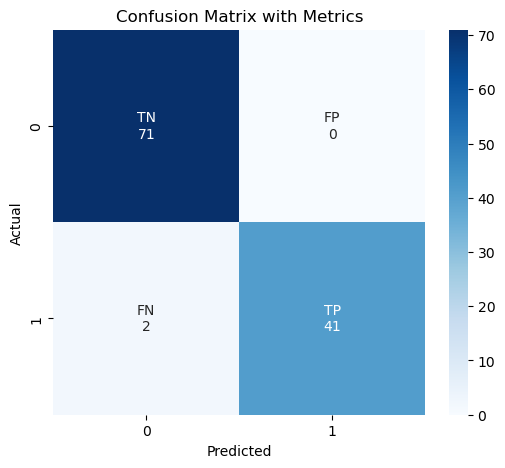

In [38]:
cm = confusion_matrix(y_test, y_pred_test)

group_names = ['TN','FP','FN','TP']
group_counts = ["{0:0.0f}".format(value)for value in cm.flatten()]

labels = [f"{v1}\n{v2}"for v1, v2 in zip(group_names, group_counts)]
labels = np.asarray(labels).reshape(2,2)

plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=labels,fmt='',cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix with Metrics")
plt.show()

In [40]:
print("Train Accuracy:", accuracy_score(y_train, y_pred_train))
print("Test Accuracy:", accuracy_score(y_test, y_pred_test))

print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test, y_pred_test))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_test))

Train Accuracy: 0.9846153846153847
Test Accuracy: 0.9824561403508771

Confusion Matrix (Test):
[[71  0]
 [ 2 41]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        71
           1       1.00      0.95      0.98        43

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



## Insight

The Logistic Regression model achieved excellent performance on both the training and testing datasets, with accuracies above 98%.

The small difference between training and testing accuracy indicates that the model generalizes well and does not show significant overfitting.

The confusion matrix also shows that the model correctly classified most samples with only a few misclassifications.

In addition, the model achieved very high precision and recall scores, especially for malignant cases, which means it was able to detect most cancer cases successfully.

Overall, the preprocessing steps, scaling, and feature selection helped improve the model performance and stability.

# ROC Curve:

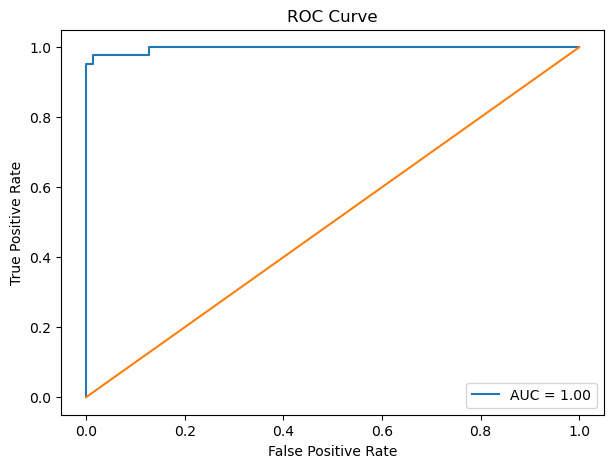

In [43]:
# Predict probabilities
y_prob = pipeline.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
# Plot ROC Curve
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## ROC Curve Insight

The ROC curve indicates that the Logistic Regression model performs extremely well in distinguishing between benign and malignant tumors.

The AUC score reached 1.00, which reflects excellent classification performance and strong predictive capability.

The curve is positioned very close to the top-left corner, indicating high sensitivity and a very low false positive rate.

Overall, the model demonstrates strong reliability in predicting breast cancer diagnosis.

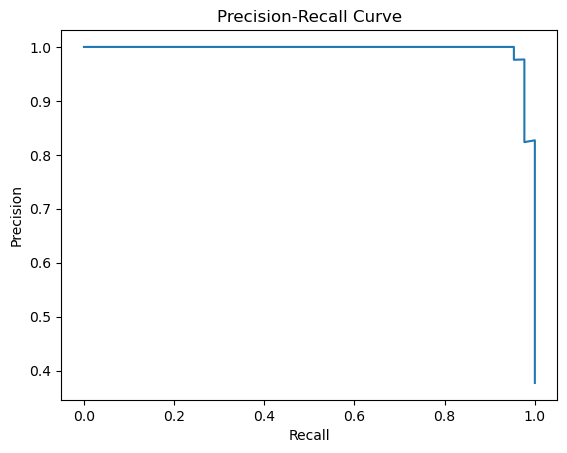

In [44]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure()
plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

# 💾 Save Model

In [45]:
with open("breast_cancer_pipeline.pkl", "wb") as f:
    pickle.dump(pipeline, f)
print("Pipeline saved successfully.")

Pipeline saved successfully.
